# Olympic Data Analysis Project


This project analyzes Olympic Games data from 1896 to 2016, providing insights into medal distributions, national performance patterns, and gender participation trends across Olympic history. Through data cleaning, aggregation, and visualization techniques, the analysis offers a comprehensive overview of global athletic achievements and evolving Olympic dynamics.

## Key Features:

- Data Cleaning and Preparation: Handles missing values, removes redundant columns, and refines event naming for improved analysis clarity
- Medal Analysis: Identifies and visualizes top 10 countries by total medal count using stacked bar charts with appropriate color coding
- Performance by Olympic Type: Separate analyses for Summer and Winter Olympics, highlighting different countries' strengths in each
 Time-Series Analysis: Tracks performance trends over multiple Olympic Games, particularly focusing on the 2012 Olympics
- Gender Participation Tracking: Visualizes the evolution of female athlete participation across top-performing nations using multi-panel plots
- Comparative Gender Analysis: Plots male versus female participation percentages over time to demonstrate the progression toward gender balance in the Olympics
- Comprehensive Visualization: Employs various chart types including bar charts, line graphs, and grid plots with consistent color-coding for easy interpretation
- Statistical Insights: Provides summary statistics and identifies patterns in Olympic participation and performance data

The project combines technical data manipulation skills with insightful visualization to tell the story of Olympic history through data.

## Setup

In [77]:
# Standard Python modules
import sys
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt

## Loading Data

In [78]:
def load_data(filename):
    return pd.read_csv(filename)

In [79]:
filename = 'olympics.csv'
df = load_data(filename)
print("Successfully loaded Paris2024_Results.csv.")

Successfully loaded Paris2024_Results.csv.


## Basic overview of the dataset

In [80]:
print("Here is the dataset overview:")
df.shape

Here is the dataset overview:


(271116, 15)

In [81]:
print("Here is what your loaded data looks like in Pandas:")
df.head()

Here is what your loaded data looks like in Pandas:


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [82]:
print("Datatypes of columns:")
df.dtypes

Datatypes of columns:


ID          int64
Name       object
Sex        object
Age       float64
Height    float64
Weight    float64
Team       object
NOC        object
Games      object
Year        int64
Season     object
City       object
Sport      object
Event      object
Medal      object
dtype: object

In [83]:
print("\nSummary of statistics:")
display(df.describe())


Summary of statistics:


,ID,Age,Height,Weight,Year
count,271116.000000,261642.000000,210945.000000,208241.000000,271116.000000
mean,68248.954396,25.556898,175.338970,70.702393,1978.378480
std,39022.286345,6.393561,10.518462,14.348020,29.877632
min,1.000000,10.000000,127.000000,25.000000,1896.000000
25%,34643.000000,21.000000,168.000000,60.000000,1960.000000
50%,68205.000000,24.000000,175.000000,70.000000,1988.000000
75%,102097.250000,28.000000,183.000000,79.000000,2002.000000
max,135571.000000,97.000000,226.000000,214.000000,2016.000000


## Data Cleaning

In [84]:
#Let's find the missing values in each column
print("Missing values:")
display(df.isnull().sum())

Missing values:


ID             0
Name           0
Sex            0
Age         9474
Height     60171
Weight     62875
Team           0
NOC            0
Games          0
Year           0
Season         0
City           0
Sport          0
Event          0
Medal     231333
dtype: int64

In [85]:
#Let's handle the missing values
#Since Age, Height, Weight, Medal has numerical values, we can fill NaN with 0.
#Doing this will not affect our final analysis result

cols = ['Age','Height','Weight','Medal']
df[cols] = df[cols].fillna(0)
print("Successfully handled Missing values")

Successfully handled Missing values


In [86]:
#We can remove the column Games because it has Year + Season which are already in separate columns
#We can also remove Team column because we use NOC data
df = df.drop(['Games','Team'],axis=1)
print("Column dropped successfully")

Column dropped successfully


In [87]:
#Let's remove Sport data from Event column to make it look more clean
df['Event'] = df.apply(lambda row: row['Event'][len(row['Sport']):].lstrip() 
                       if row['Event'].startswith(row['Sport']) else row['Event'], axis=1)
print("Cleaned Event column data")

Cleaned Event column data


## Data Analysis

### TASK 1: To find Top 10 countries with Total Medals - Gold, Silver or Bronze and plot it using barchart

In [88]:
#We are creating a new dataframe from existing df to filter out 0 medal values
medal_df = df[df['Medal'].isin(['Gold', 'Silver', 'Bronze'])]

# We are grouping by country code(NOC) and medal, then we count the Medal values, and reshape so that it counts medal category wise
medal_count = medal_df.groupby('NOC')['Medal'].value_counts().unstack(fill_value=0)

# Add a total column
medal_count['Total'] = medal_count.sum(axis=1)

# Get top 10 countries by total medals
top_10 = medal_count.sort_values(by='Total', ascending=False).head(10)

#### Plotting in a bar chart

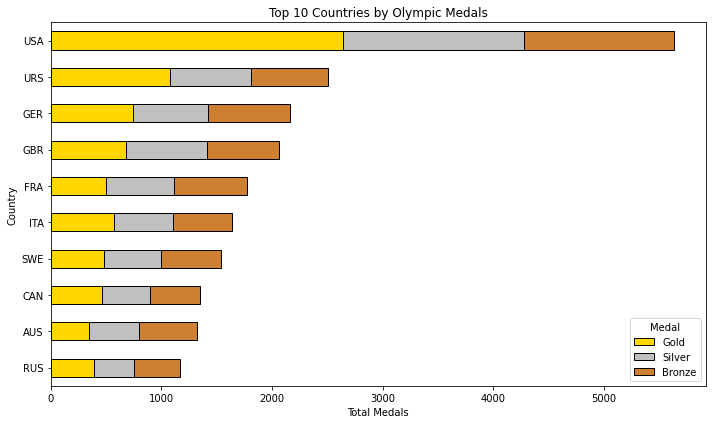

In [89]:
colors = ['gold', 'silver', '#CD7F32']

top_10[['Gold', 'Silver', 'Bronze']].plot(
    kind='barh',
    stacked=True,
    figsize=(10, 6),
    color=colors,
    edgecolor='black'
)

plt.xlabel('Total Medals')
plt.ylabel('Country')
plt.title('Top 10 Countries by Olympic Medals')
plt.gca().invert_yaxis()  
plt.tight_layout()
plt.show()

### TASK 2: To find top 5 winning countries - 2012 Olympics and plot it in a bar chart

In [90]:
#We are creating a new dataframe from existing df to filter out Gold medal values
gold_df = medal_df[(medal_df['Medal']=='Gold') & (medal_df['Year']==2012)]

unique_gold_df = gold_df.drop_duplicates(subset=['NOC', 'Event'])

top_5_countries_df = unique_gold_df.groupby('NOC')['Medal'].count().reset_index()
top_5_countries_df = top_5_countries_df.sort_values(by='Medal',ascending=False)
top_5_countries_df = top_5_countries_df.head(5)

#### Visualizing top 5 winning countries - 2012 Olympics in Bar chart

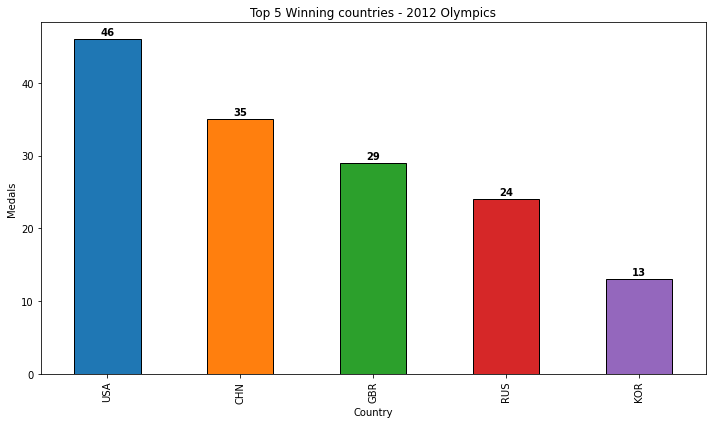

In [91]:


colors = ['#1f77b4','#ff7f0e','#2ca02c', '#d62728', '#9467bd']

ax=top_5_countries_df.set_index('NOC')['Medal'].plot(
    kind='bar',
    figsize=(10, 6),
    edgecolor='black',
    color=colors
)

for i, v in enumerate(top_5_countries_df['Medal']):
    ax.text(i, v + 0.5, str(v), ha='center', fontweight='bold')

plt.xlabel('Country')
plt.ylabel('Medals')
plt.title('Top 5 Winning countries - 2012 Olympics')  
plt.tight_layout()
plt.show()

### TASK 3: To find top 10 countries that excel in summer olympics

In [92]:
summer_df = medal_df[(medal_df['Medal']=='Gold') & (medal_df['Season']=='Summer')]
summer_df.head()

unique_gold_summer = summer_df.drop_duplicates(subset=['NOC', 'Event'])


top_10_summer = unique_gold_summer.groupby('NOC')['Medal'].count().reset_index()
top_10_summer = top_10_summer.sort_values(by='Medal',ascending=False)
top_10_summer = top_10_summer.head(10)
top_10_summer = top_10_summer.reset_index(drop=True)
top_10_summer

,NOC,Medal
0,USA,259
1,GBR,162
2,URS,153
3,GER,142
4,FRA,141
5,ITA,108
6,GDR,94
7,RUS,91
8,SWE,87
9,AUS,84


### TASK 4: To find top 10 countries that excel in winter olympics

In [93]:
winter_df = medal_df[(medal_df['Medal']=='Gold') & (medal_df['Season']=='Winter')]
winter_df.head()

unique_gold_winter = winter_df.drop_duplicates(subset=['NOC', 'Event'])


top_10_winter = unique_gold_winter.groupby('NOC')['Medal'].count().reset_index()
top_10_winter = top_10_winter.sort_values(by='Medal',ascending=False)
top_10_winter = top_10_winter.head(10)
top_10_winter = top_10_winter.reset_index(drop=True)
top_10_winter

,NOC,Medal
0,NOR,41
1,GER,40
2,USA,37
3,CAN,35
4,RUS,32
5,URS,26
6,SWE,26
7,SUI,25
8,AUT,22
9,FIN,22


### TASK 5: Summer VS Winter Winning Comparison for top 10 countries

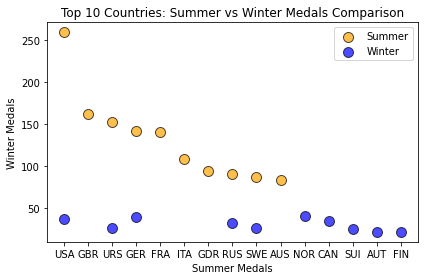

In [94]:
# Scatter plot for Summer medals
plt.scatter(top_10_summer["NOC"], top_10_summer["Medal"], 
            label="Summer", color='orange', s=100, alpha=0.7, edgecolors='black', marker='o')

# Scatter plot for Winter medals
plt.scatter(top_10_winter["NOC"], top_10_winter["Medal"], 
            label="Winter", color='blue', s=100, alpha=0.7, edgecolors='black', marker='o')

plt.xlabel("Summer Medals")
plt.ylabel("Winter Medals")
plt.title("Top 10 Countries: Summer vs Winter Medals Comparison")
plt.legend()
plt.tight_layout()
plt.show()

### TASK 6: Visualize the changes in female athelete participation in Summer Olympics in the top 10 winning countries (Refer TASK 3)

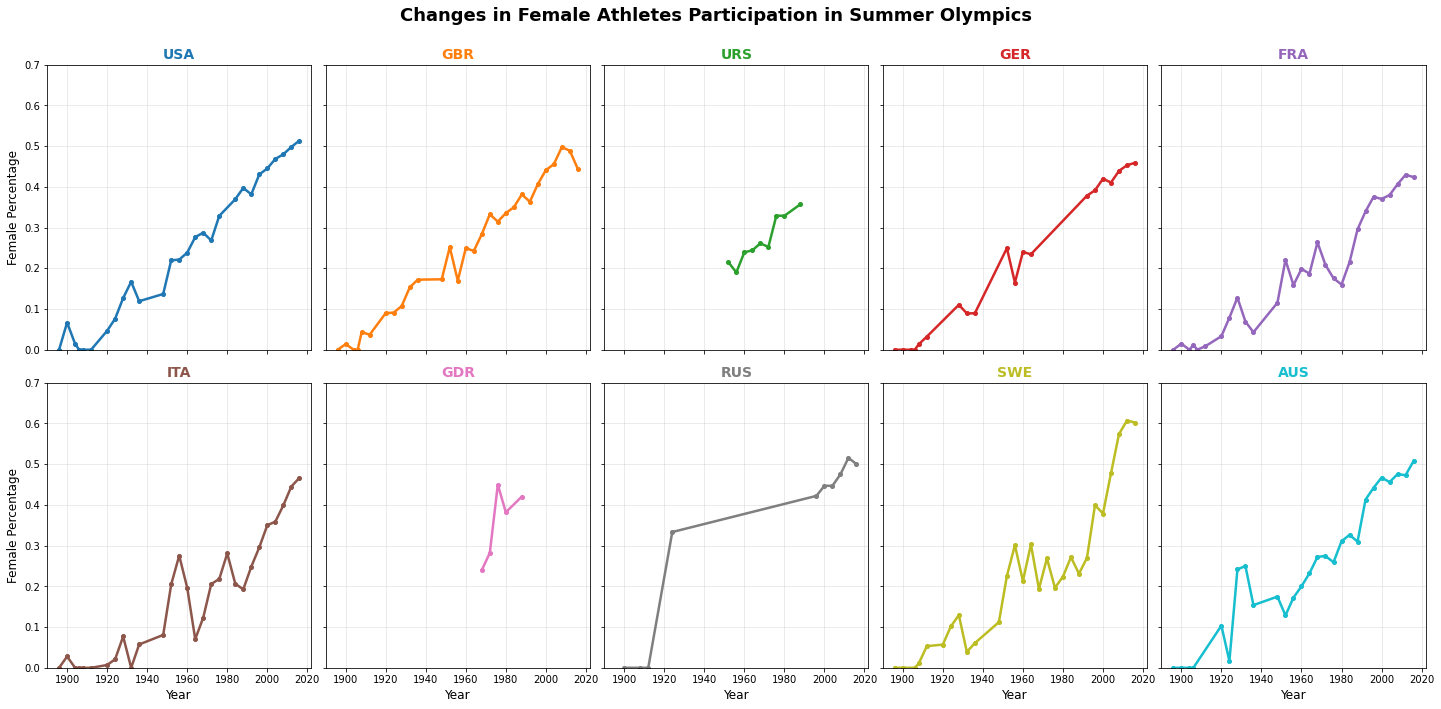

In [95]:
#Filter for Summer Olympics only
summer_df = df[df['Season'] == 'Summer']

#Getting the list of NOC's from the TASK 3
selected_nocs = top_10_summer['NOC']

#Filtering dataframe for selected NOCs
noc_df = summer_df[summer_df['NOC'].isin(selected_nocs)]

#To calculate the number of male and female athletes, we filter based on Year, NOC, Sex
gender_percentage_df = noc_df.groupby(['Year', 'NOC', 'Sex']).size().unstack(fill_value=0)

if 'F' in gender_percentage_df.columns and 'M' in gender_percentage_df.columns:
    gender_percentage_df['Total'] = gender_percentage_df['F'] + gender_percentage_df['M']
    gender_percentage_df['Female_Percentage'] = gender_percentage_df['F'] / gender_percentage_df['Total']

gender_percentage_df = gender_percentage_df.reset_index()

#Creating a 2x5 grid subplots for the selected NOC's
fig, axes = plt.subplots(2, 5, figsize=(20, 10), sharex=True, sharey=True)
axes = axes.flatten()

#Selecting unique color for each country
colors = {
    'USA': '#1f77b4',  
    'GBR': '#ff7f0e',  
    'URS': '#2ca02c', 
    'GER': '#d62728', 
    'FRA': '#9467bd', 
    'ITA': '#8c564b',  
    'GDR': '#e377c2', 
    'RUS': '#7f7f7f',  
    'SWE': '#bcbd22', 
    'AUS': '#17becf'
}

#Plotting each NOC as a separate plot
for i, noc in enumerate(selected_nocs):
    noc_data = gender_percentage_df[gender_percentage_df['NOC'] == noc]
    
    if not noc_data.empty:
        #Plot the female percentage over time
        axes[i].plot(noc_data['Year'], noc_data['Female_Percentage'], 
                   color=colors[noc], linewidth=2.5, marker='o', markersize=4)
        
        axes[i].set_title(f'{noc}', fontsize=14, fontweight='bold', color=colors[noc])
        axes[i].grid(True, alpha=0.3)
        
        #Set y-axis limits consistently across all plots
        axes[i].set_ylim(0, 0.7)  
        
        #Add axis labels only for the outer subplots
        if i >= 5:  
            axes[i].set_xlabel('Year', fontsize=12)
        if i % 5 == 0: 
            axes[i].set_ylabel('Female Percentage', fontsize=12)

plt.suptitle('Changes in Female Athletes Participation in Summer Olympics', 
             fontsize=18, fontweight='bold', y=0.98)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(top=0.9)

# Show plot
plt.show()

### TASK 7: Compare Male and Female Atheletes Participation over the years

In [96]:
summer_df = df[df['Season'] == 'Summer']

gender_counts = summer_df.groupby(['Year', 'Sex']).size().unstack(fill_value=0)

#Filter only years where both genders participated
gender_counts = gender_counts[gender_counts['M'] > 0]

#Calculate participation percentages
gender_counts['Total'] = gender_counts['F'] + gender_counts['M']
gender_counts['Female_Percentage'] = gender_counts['F'] / gender_counts['Total']
gender_counts['Male_Percentage'] = gender_counts['M'] / gender_counts['Total']


#### Plotting Male VS Female Participation over the years

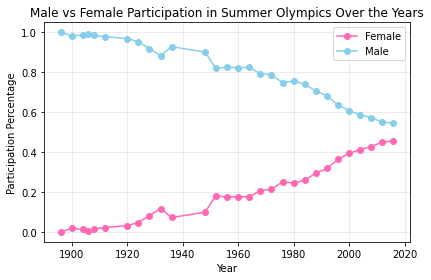

In [97]:
plt.plot(gender_counts.index, gender_counts['Female_Percentage'], label='Female', color='hotpink', marker='o')
plt.plot(gender_counts.index, gender_counts['Male_Percentage'], label='Male', color='skyblue', marker='o')
plt.xlabel("Year")
plt.ylabel("Participation Percentage")
plt.title("Male vs Female Participation in Summer Olympics Over the Years")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# CONCLUSION

- This project explored over a century of Olympic history, revealing insights into medal distributions, national performance, 
and gender participation trends. 
- We found that countries like the USA, GBR, and Russia have consistently dominated both Summer and Winter Games. 
- Female participation in the Summer Olympics has shown a steady increase across top-performing nations, highlighting progress 
in gender representation. 
- By combining data cleaning, aggregation, and visualization techniques, this analysis offers a meaningful snapshot of global 
athletic achievement and evolving Olympic dynamics.
